# SARIMA Model

## Objective

This notebook develops a Seasonal Autoregressive Integrated Moving Average (SARIMA) model to forecast weekly German electricity demand.

The model parameters are selected using the Akaike Information Criterion (AIC). The fitted model is evaluated using residual diagnostics and forecasting accuracy metrics.

In [22]:
# Import required libraries

import warnings
warnings.filterwarnings("ignore")

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

## Load Weekly Electricity Demand

The processed weekly electricity demand series is loaded and divided into training and testing datasets. The final two years (104 weeks) are reserved for forecast evaluation.

In [23]:
# Load weekly electricity demand

weekly_load = pd.read_csv(
    "/content/weekly_load.csv",
    parse_dates=["timestamp"],
    index_col="timestamp"
)

weekly_load.head()

,load
timestamp,
2015-01-04 00:00:00+00:00,47233.739583
2015-01-11 00:00:00+00:00,56191.101190
2015-01-18 00:00:00+00:00,57672.678571
2015-01-25 00:00:00+00:00,58613.303571
2015-02-01 00:00:00+00:00,58734.029762


## Train-Test Split

The weekly electricity demand dataset is divided into training and testing sets.

The final 104 weekly observations are reserved for evaluating the forecasting performance of the SARIMA model.

In [24]:
# Split into training and testing data

forecast_horizon = 104

train = weekly_load.iloc[:-forecast_horizon]

test = weekly_load.iloc[-forecast_horizon:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 197
Testing observations: 104


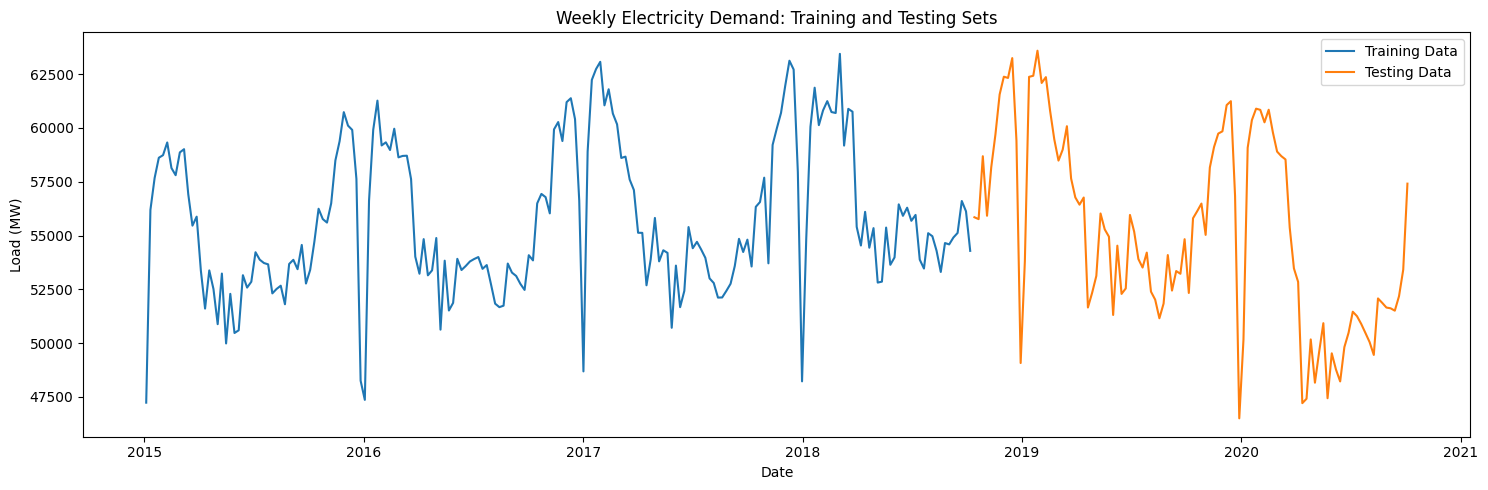

In [25]:
# Plot training and testing datasets

plt.figure(figsize=(15,5))

plt.plot(
    train.index,
    train["load"],
    label="Training Data"
)

plt.plot(
    test.index,
    test["load"],
    label="Testing Data"
)

plt.title("Weekly Electricity Demand: Training and Testing Sets")

plt.xlabel("Date")
plt.ylabel("Load (MW)")

plt.legend()

plt.tight_layout()

plt.savefig(
    "train_test_split.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Forecast Evaluation Function

The SARIMA model will be evaluated using the following performance metrics:

- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)
- Mean Absolute Percentage Error (MAPE)

These metrics will be used consistently across all forecasting models for comparison.

In [26]:
def evaluate_forecast(actual, forecast):

    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mae = mean_absolute_error(actual, forecast)
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    }

## SARIMA Model Selection

Several candidate SARIMA models were evaluated using the Akaike Information Criterion (AIC). The candidate models were selected based on insights from the stationarity analysis and ACF/PACF plots. The model with the lowest AIC value was selected for forecasting.

In [27]:
# Candidate SARIMA models

candidate_models = [

    ((1,1,0), (0,1,1,52)),
    ((1,1,1), (0,1,1,52)),
    ((2,1,1), (0,1,1,52)),
    ((1,1,2), (0,1,1,52)),
    ((2,1,2), (0,1,1,52)),

    ((1,1,0), (1,1,1,52)),
    ((1,1,1), (1,1,1,52)),
    ((2,1,1), (1,1,1,52))

]

In [28]:
# Fit each candidate model and record the AIC

results = []

for order, seasonal_order in candidate_models:

    try:

        model = SARIMAX(
            train["load"],
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted_model = model.fit(disp=False)

        results.append({
            "ARIMA": order,
            "Seasonal": seasonal_order,
            "AIC": fitted_model.aic
        })

    except:

        continue

In [29]:
# Display the candidate models ranked by AIC

results_df = pd.DataFrame(results)

results_df = results_df.sort_values("AIC")

results_df.reset_index(drop=True, inplace=True)

results_df

,ARIMA,Seasonal,AIC
0,"(1, 1, 2)","(0, 1, 1, 52)",1562.590002
1,"(2, 1, 2)","(0, 1, 1, 52)",1563.881880
2,"(1, 1, 1)","(0, 1, 1, 52)",1578.405017
3,"(2, 1, 1)","(0, 1, 1, 52)",1579.185799
4,"(1, 1, 1)","(1, 1, 1, 52)",1579.985178
5,"(2, 1, 1)","(1, 1, 1, 52)",1585.699488
6,"(1, 1, 0)","(1, 1, 1, 52)",1606.406259
7,"(1, 1, 0)","(0, 1, 1, 52)",1610.769464


In [30]:
results_df.to_csv(
    "sarima_model_selection.csv",
    index=False
)

In [31]:
# Select the model with the lowest AIC

best_order = results_df.iloc[0]["ARIMA"]

best_seasonal = results_df.iloc[0]["Seasonal"]

print("Best ARIMA Order:", best_order)

print("Best Seasonal Order:", best_seasonal)

Best ARIMA Order: (1, 1, 2)
Best Seasonal Order: (0, 1, 1, 52)


## Final SARIMA Model

Based on the AIC comparison, the SARIMA(1,1,2)(0,1,1,52) model was selected as the final forecasting model. The model was fitted using the training dataset before generating forecasts for the testing period.

In [32]:
# Fit the final SARIMA model

sarima_model = SARIMAX(
    train["load"],
    order=(1, 1, 2),
    seasonal_order=(0, 1, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_results = sarima_model.fit(disp=False)

print(sarima_results.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                 load   No. Observations:                  197
Model:             SARIMAX(1, 1, 2)x(0, 1, [1], 52)   Log Likelihood                -776.295
Date:                              Wed, 01 Jul 2026   AIC                           1562.590
Time:                                      00:14:04   BIC                           1575.033
Sample:                                  01-04-2015   HQIC                          1567.605
                                       - 10-07-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5037      0.300      1.681      0.093      -0.083       1.091
ma.L1         -1.13

## Residual Diagnostics

Residual diagnostics were performed to evaluate the adequacy of the fitted SARIMA model. The residuals were inspected visually to assess whether they resembled white noise.

In [33]:
# Extract model residuals

residuals = sarima_results.resid

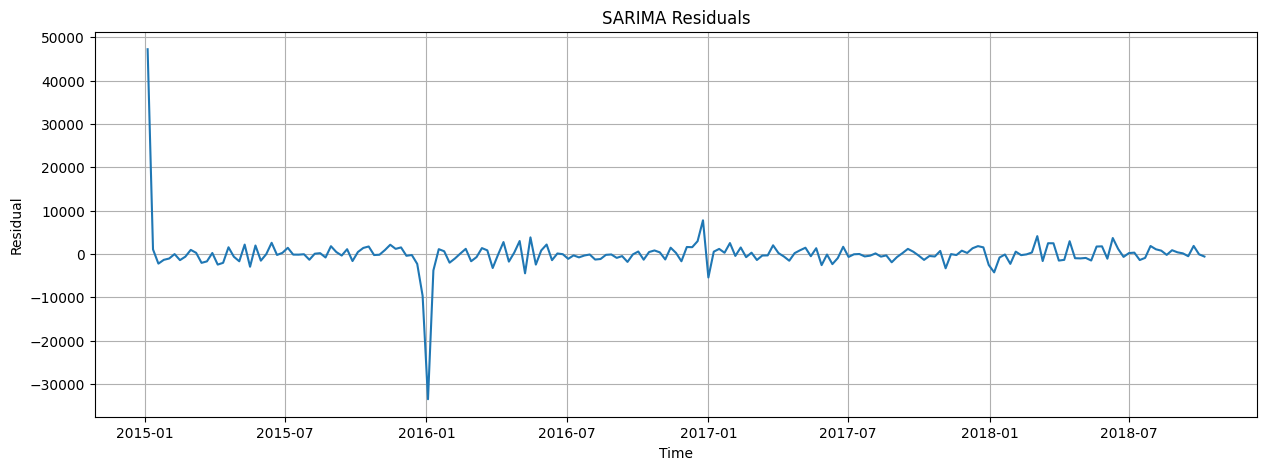

In [34]:
plt.figure(figsize=(15,5))

plt.plot(residuals)

plt.title("SARIMA Residuals")

plt.xlabel("Time")

plt.ylabel("Residual")

plt.grid(True)

plt.savefig(
    "sarima_residuals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

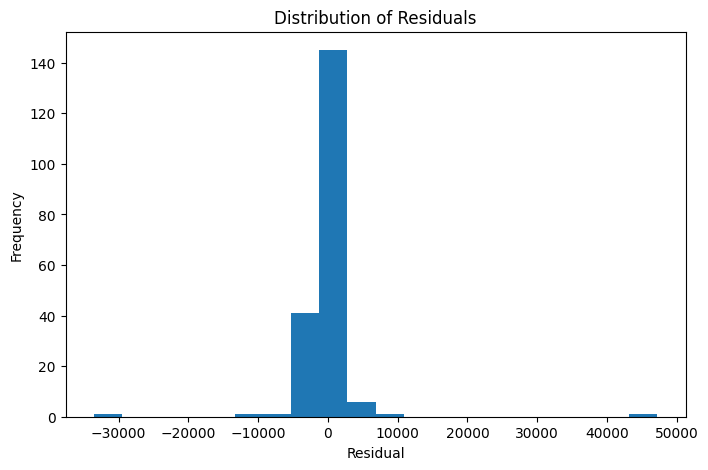

In [35]:
plt.figure(figsize=(8,5))

plt.hist(residuals, bins=20)

plt.title("Distribution of Residuals")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.savefig(
    "sarima_residual_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

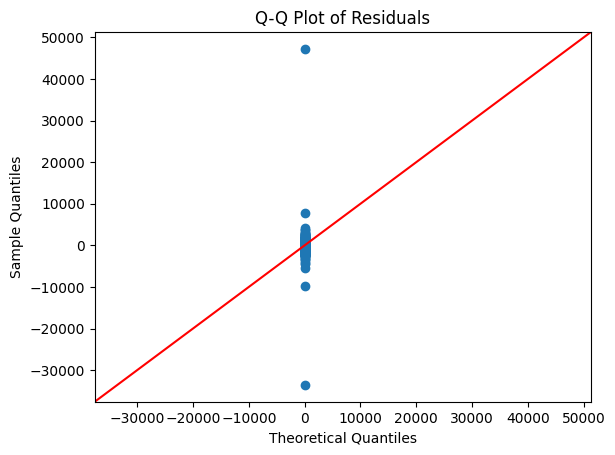

In [36]:
from statsmodels.graphics.gofplots import qqplot

qqplot(residuals, line="45")

plt.title("Q-Q Plot of Residuals")

plt.savefig(
    "sarima_qq_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    residuals,
    lags=[10],
    return_df=True
)

print(ljung_box)

     lb_stat  lb_pvalue
10  3.793734   0.956173
